In [ ]:
import importlib
import functions2 as fct
importlib.reload(fct)

<module 'functions2' from '/Users/kylemcgillivray/Python/Dissertation/Masters-Dissertation/functions2.py'>

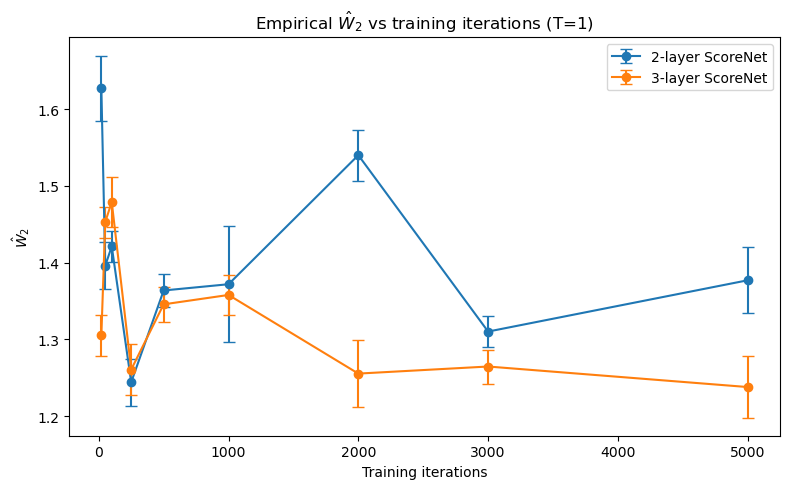

In [12]:
results_T1 = fct.load_results("outputs/results_T1.pt")
fct.plot_W2_curve(results_T1, title_suffix="(T=1)")

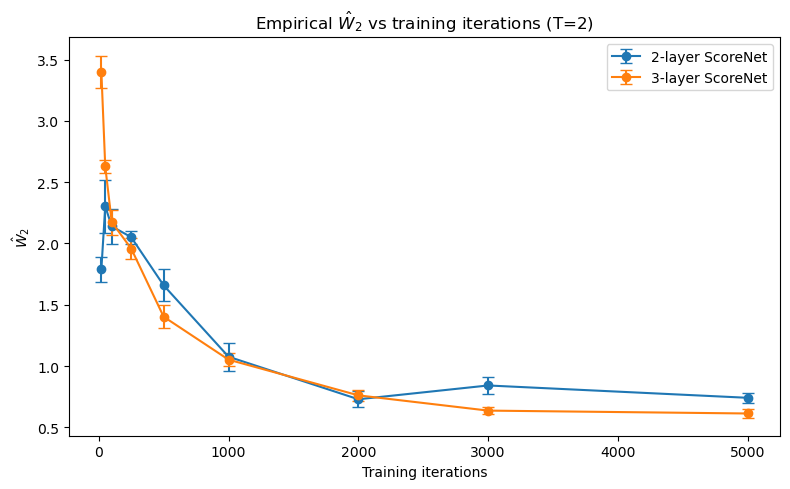

In [10]:
results_T2 = fct.load_results("outputs/results_T2.pt")
fct.plot_W2_curve(results_T2, title_suffix="(T=2)")

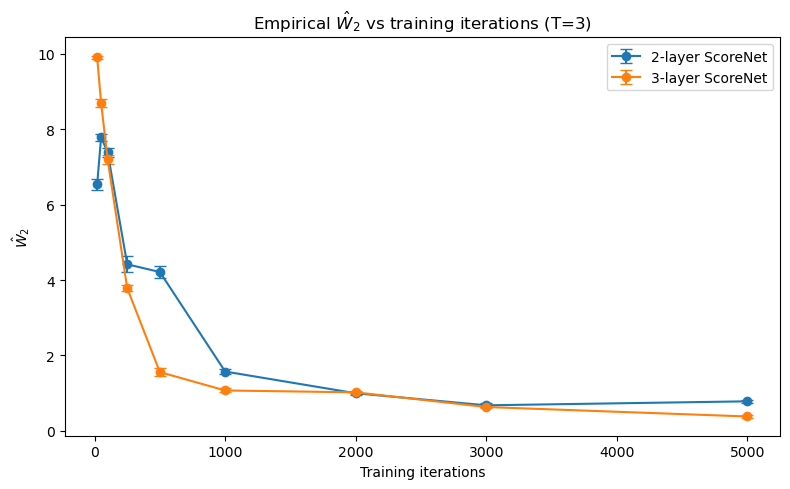

In [14]:
results_T3 = fct.load_results("outputs/results_T3.pt")
fct.plot_W2_curve(results_T3, title_suffix="(T=3)")

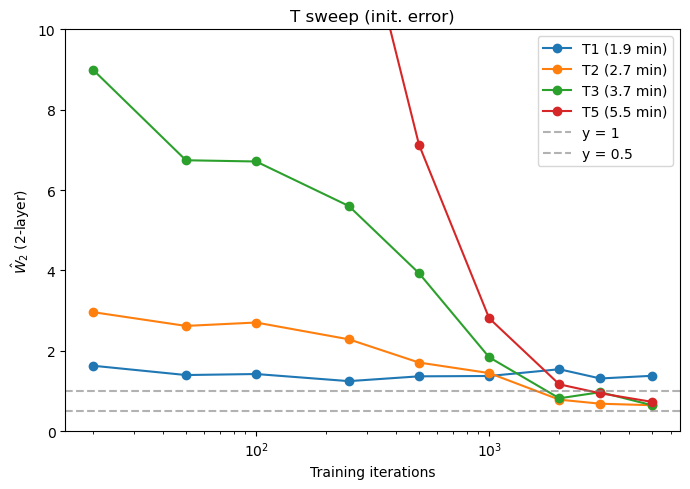

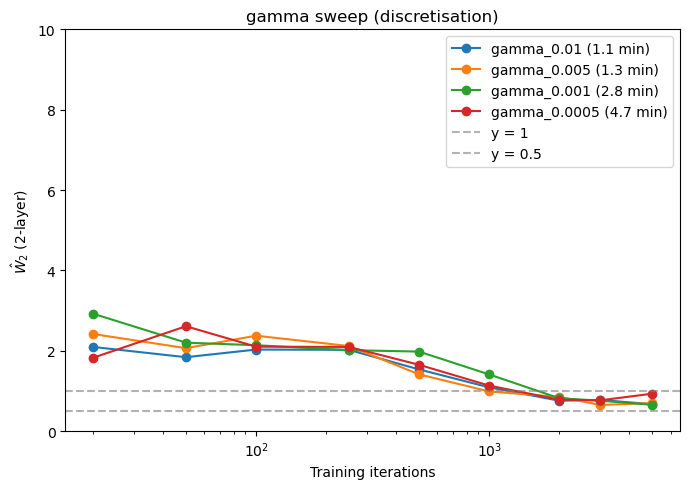

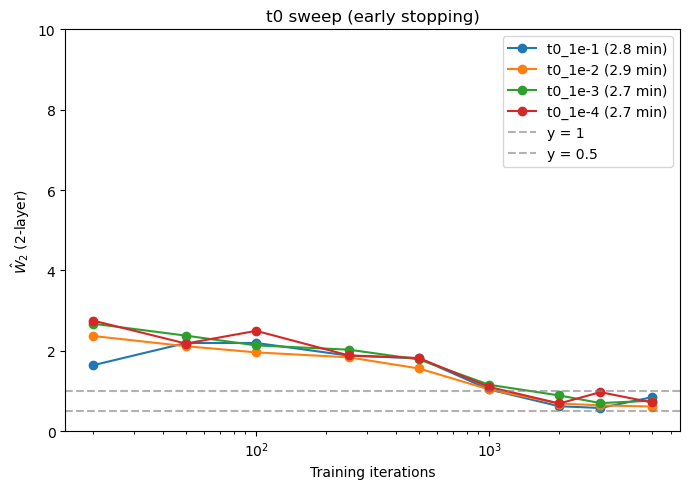

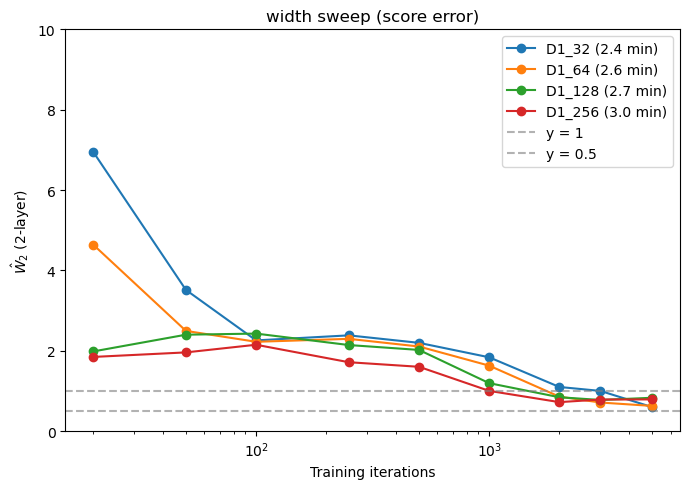

In [17]:
import functions2 as fct
import matplotlib.pyplot as plt

groups = {
    "T sweep (init. error)": ["T1", "T2", "T3", "T5"],
    "gamma sweep (discretisation)": ["gamma_0.01", "gamma_0.005", "gamma_0.001", "gamma_0.0005"],
    "t0 sweep (early stopping)": ["t0_1e-1", "t0_1e-2", "t0_1e-3", "t0_1e-4"],
    "width sweep (score error)": ["D1_32", "D1_64", "D1_128", "D1_256"],
}

all_results = {}
for group_name, tags in groups.items():
    all_results[group_name] = {tag: fct.load_results(f"outputs/results_{tag}.pt") for tag in tags}

for group_name, results_by_tag in all_results.items():
    plt.figure(figsize=(7, 5))
    for tag, results in results_by_tag.items():
        runtime = results.get("runtime_seconds")
        label = f"{tag}" + (f" ({runtime/60:.1f} min)" if runtime else "")
        plt.plot(results["checkpoints"], results["W2_2layer_curve"], marker='o', label=label)

    plt.axhline(y=1, linestyle='--', color='gray', alpha=0.6, label='y = 1')
    plt.axhline(y=0.5, linestyle='--', color='gray', alpha=0.6, label='y = 0.5')

    plt.xlabel("Training iterations")
    plt.ylabel(r"$\hat{W}_2$ (2-layer)")
    plt.xscale('log')
    plt.ylim(0, 10)
    plt.title(group_name)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
import functions2 as fct
import numpy as np

fct.set_seed(0)
device = fct.get_device()

d = 2
mu1, mu2 = np.array([1.3, 1.3]), np.array([-1.3, -1.3])
X_data_bimodal = fct.sample_bimodal_data(N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=1.0, weight=0.5)

iter 500/5000, loss = 1.4115
iter 1000/5000, loss = 1.3983
iter 1500/5000, loss = 1.0579
iter 2000/5000, loss = 1.0829
iter 2500/5000, loss = 4.0778
iter 3000/5000, loss = 1.2927
iter 3500/5000, loss = 1.3896
iter 4000/5000, loss = 2.9360
iter 4500/5000, loss = 1.6492
iter 5000/5000, loss = 1.2708


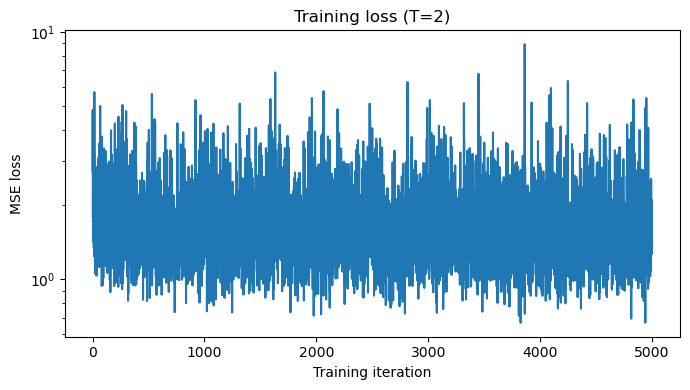

In [7]:
# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
T = 2
net = fct.ScoreNet(d=d, D_1=128)  # swap for fct.ScoreNet3(d=d, D_1=128, D_2=128) to try the 3-layer net

net, loss_history = fct.train_network(
    net, X_data_bimodal, t_0=1e-3, T=T, d=d,
    n_iters=5000, batch_size=512, lr=1e-3, device=device, print_every=500
)

fct.plot_loss_curve(loss_history, title_suffix=f"(T={T})")

In [11]:
# ------------------------------------------------------------
# Sample
# ------------------------------------------------------------
N_samples = 1_000_000
samples = fct.euler_maruyama_sample_nn_batch(
    net, gamma=0.001, T=T, d=d, N_samples=N_samples, device=device
)

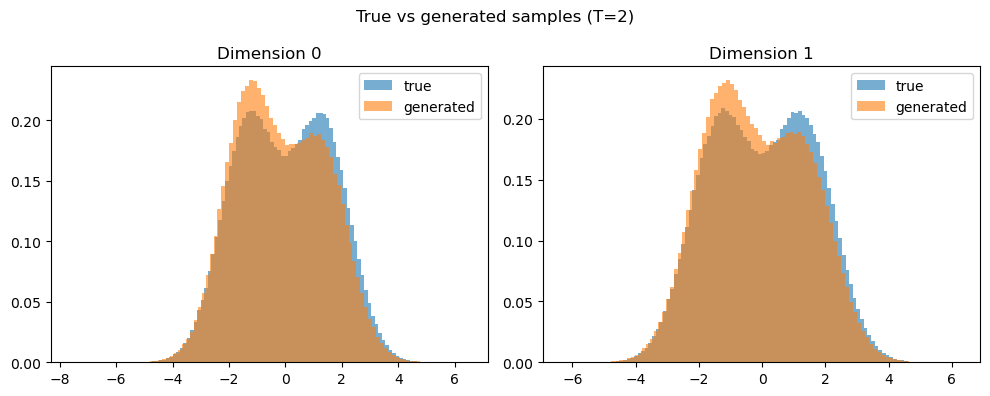

In [12]:
# ------------------------------------------------------------
# Display: true distribution vs generated samples
# ------------------------------------------------------------
fct.plot_true_vs_generated(X_data_bimodal, samples, d=d, title_suffix=f"(T={T})")

In [42]:
# ------------------------------------------------------------
# Wasserstein-2 distance
# ------------------------------------------------------------
N_w2 = 2000
w2 = fct.wasserstein2_distance(samples[:N_w2], X_data_bimodal[:N_w2])
print(f"W2(generated, true) = {w2:.4f}")

W2(generated, true) = 0.4037


In [43]:
import functions3 as fct
import numpy as np
import matplotlib.pyplot as plt

results = fct.load_results("outputs/gridsearch3_results.pt")
print(f"{len(results)} configs loaded")

36 configs loaded


In [44]:
# ------------------------------------------------------------

# True data, and the W2 noise floor: the W2 distance between two
# INDEPENDENT samples, both drawn from the true pi_D. This is the
# minimum W2 achievable by any network at this sample size - it's
# finite-sample estimator bias, not model error, so no amount of
# training can beat it.
# ------------------------------------------------------------
d = 2
mu1 = np.array([1.3, 1.3])
mu2 = np.array([-1.3, -1.3])
sigma_mix = 1.0
weight = 0.5

X_data_bimodal = fct.sample_bimodal_data(
    N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)

w2_floor_mean, w2_floor_std = fct.W2_self_floor(X_data_bimodal, N=2000, n_repeats=5)
print(f"W2 noise floor (N=2000): {w2_floor_mean:.4f} ± {w2_floor_std:.4f}")

W2 noise floor (N=2000): 0.1977 ± 0.0202


In [45]:
# 5 LAYER
ranked = sorted(results.items(), key=lambda kv: kv[1]["w2_mean"])

print(f"{'tag':45s} {'W2':>18s} {'final_loss':>12s}")
for tag, r in ranked:
    print(f"{tag:45s} {r['w2_mean']:.4f} ± {r['w2_std']:.4f}  {r['final_loss']:12.4f}")

best_tag = ranked[0][0]
print(f"\nBest config: {best_tag}")

tag                                                           W2   final_loss
theopoula_lam0.02_eps0.2_beta1e+10_r2         0.1905 ± 0.0154        0.6857
theopoula_lam0.02_eps0.1_beta1e+10_r1.5       0.1994 ± 0.0228        0.6859
theopoula_lam0.01_eps0.1_beta1e+10_r0         0.2005 ± 0.0102        0.6845
theopoula_lam0.005_eps0.2_beta1e+12_r0        0.2038 ± 0.0057        0.6858
theopoula_lam0.02_eps0.1_beta1e+10_r2         0.2116 ± 0.0160        0.6864
theopoula_lam0.01_eps0.2_beta1e+12_r2         0.2182 ± 0.0132        0.6877
theopoula_lam0.005_eps0.2_beta1e+10_r1.5      0.2205 ± 0.0068        0.6861
theopoula_lam0.02_eps0.2_beta1e+10_r1.5       0.2227 ± 0.0111        0.6846
theopoula_lam0.02_eps0.1_beta1e+12_r2         0.2234 ± 0.0186        0.6860
theopoula_lam0.01_eps0.1_beta1e+12_r1.5       0.2263 ± 0.0233        0.6867
theopoula_lam0.005_eps0.1_beta1e+12_r2        0.2300 ± 0.0271        0.6848
theopoula_lam0.005_eps0.1_beta1e+10_r1.5      0.2307 ± 0.0183        0.6852
theopoula_

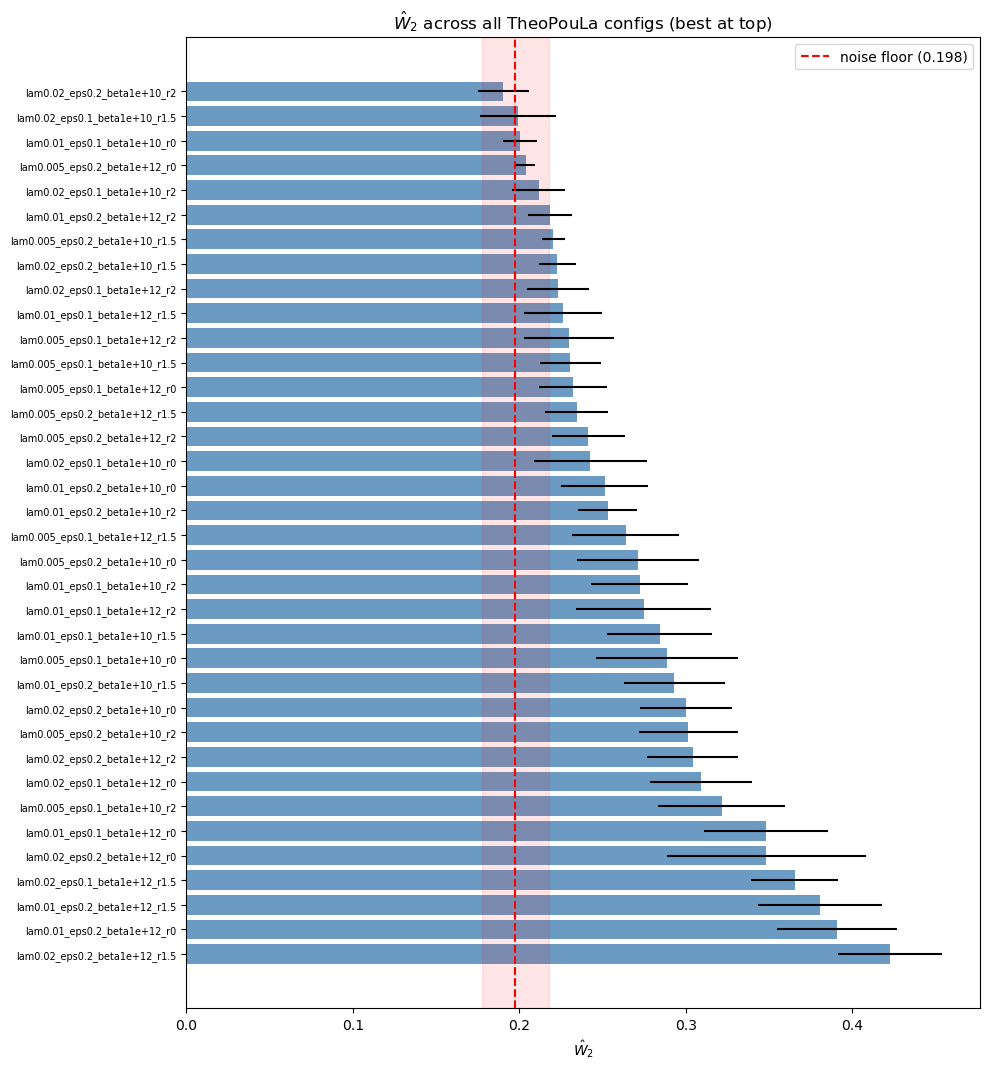

In [46]:
# 5 LAYER
tags = [tag for tag, _ in ranked]
means = [r["w2_mean"] for _, r in ranked]
stds = [r["w2_std"] for _, r in ranked]

plt.figure(figsize=(10, max(6, 0.3 * len(tags))))
plt.barh(range(len(tags)), means, xerr=stds, color="steelblue", alpha=0.8)
plt.axvline(w2_floor_mean, color="red", linestyle="--", label=f"noise floor ({w2_floor_mean:.3f})")
plt.axvspan(w2_floor_mean - w2_floor_std, w2_floor_mean + w2_floor_std, color="red", alpha=0.1)
plt.yticks(range(len(tags)), [t.replace("theopoula_", "") for t in tags], fontsize=7)
plt.xlabel(r"$\hat{W}_2$")
plt.title(r"$\hat{W}_2$ across all TheoPouLa configs (best at top)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

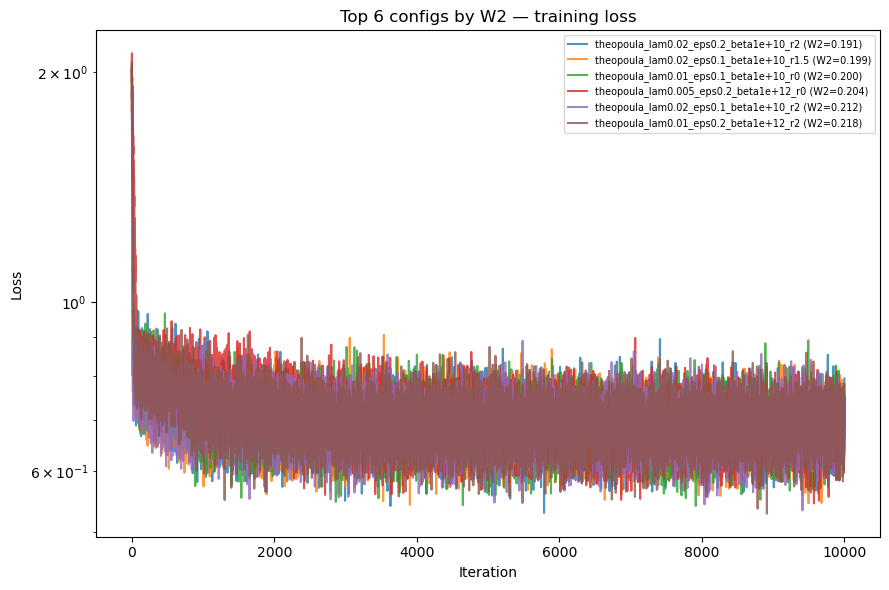

In [47]:
# 5 LAYER
top_n = 6
plt.figure(figsize=(9, 6))
for tag, r in ranked[:top_n]:
    plt.plot(r["loss_history"], label=f"{tag} (W2={r['w2_mean']:.3f})", alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title(f"Top {top_n} configs by W2 — training loss")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

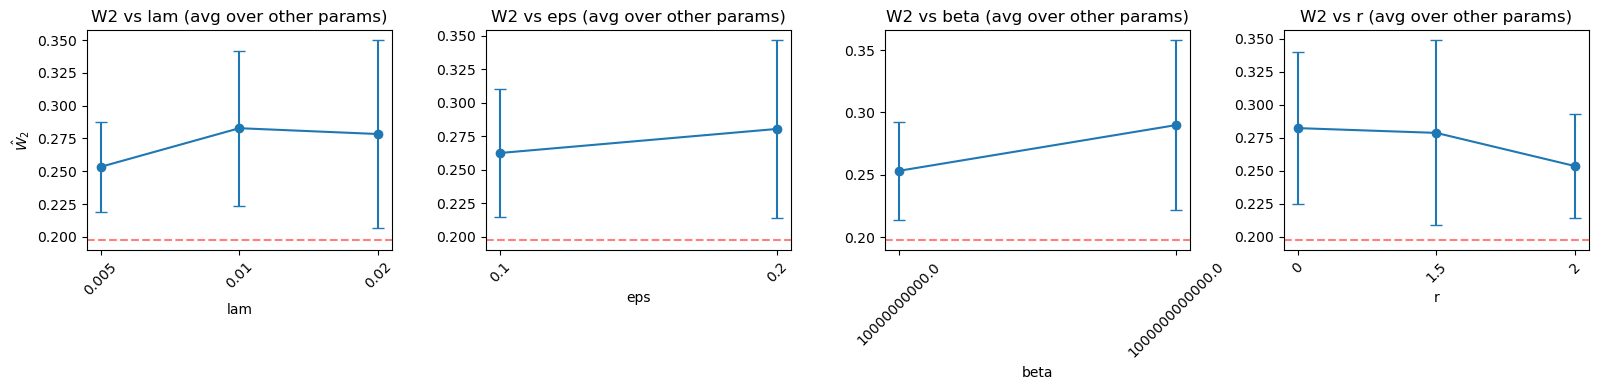

In [48]:
# 5 LAYER
config_keys = ["lam", "eps", "beta", "r"]

fig, axes = plt.subplots(1, len(config_keys), figsize=(4 * len(config_keys), 4))
for ax, key in zip(axes, config_keys):
    grouped = {}
    for tag, r in results.items():
        val = r["config"][key]
        grouped.setdefault(val, []).append(r["w2_mean"])

    xs = sorted(grouped.keys())
    means = [np.mean(grouped[x]) for x in xs]
    stds = [np.std(grouped[x]) for x in xs]

    ax.errorbar(range(len(xs)), means, yerr=stds, marker="o", capsize=4)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([str(x) for x in xs], rotation=45)
    ax.axhline(w2_floor_mean, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel(key)
    ax.set_title(f"W2 vs {key} (avg over other params)")
axes[0].set_ylabel(r"$\hat{W}_2$")
plt.tight_layout()
plt.show()

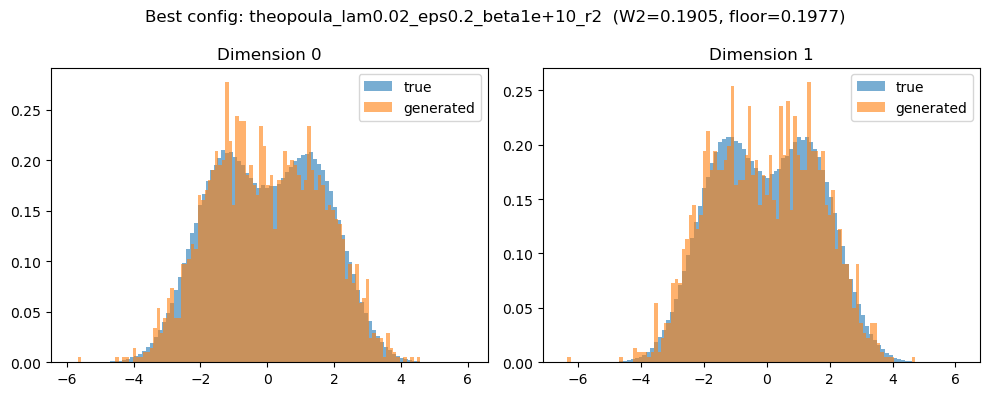

In [49]:
# 5 LAYER
best_res = results[best_tag]
samples_best = best_res["samples"]

fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, label="true", density=True)
    axes[i].hist(samples_best[:, i], bins=100, alpha=0.6, label="generated", density=True)
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle(f"Best config: {best_tag}  (W2={best_res['w2_mean']:.4f}, floor={w2_floor_mean:.4f})")
plt.tight_layout()
plt.show()

In [50]:
# ------------------------------------------------------------
# 5 LAYER
# Sample 200,000 points from the best config's trained network,
# for a much less noisy visual comparison than the 2000 points
# saved during the grid search.
# ------------------------------------------------------------
device = fct.get_device()

best_tag = "theopoula_lam0.02_eps0.2_beta1e+10_r2"   # best by W2 from the ranked table
best_config = results[best_tag]["config"]

net_best = fct.ScoreNetDeep(d=d, hidden_dims=[128] * 4).to(device)
net_best.load_state_dict(results[best_tag]["net_state"])

samples_best_200k = fct.euler_maruyama_sample_nn_batch(
    net_best, gamma=0.001, T=2, d=d, N_samples=200_000, device=device
)

print(f"Sampled {samples_best_200k.shape[0]} points from {best_tag}")

Sampled 200000 points from theopoula_lam0.02_eps0.2_beta1e+10_r2


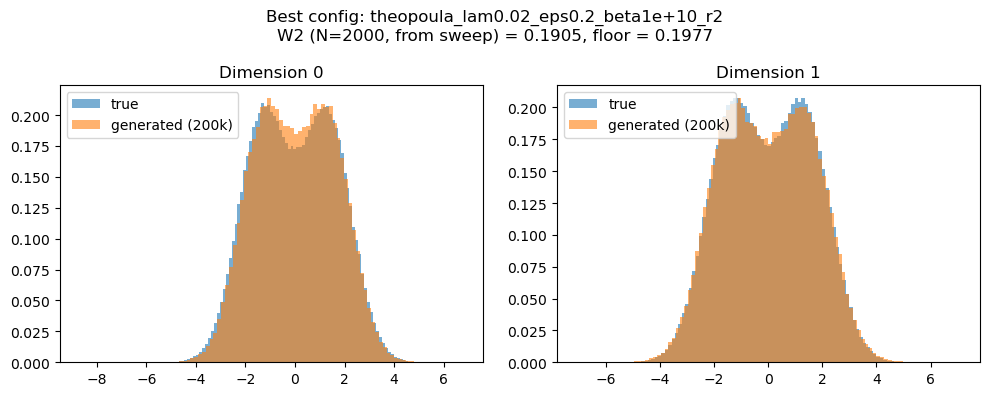

In [51]:
# ------------------------------------------------------------
# 5 LAYER
# True vs generated, using the 200k-sample draw for a smoother
# comparison than the 2000-point version stored during the sweep.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, label="true", density=True)
    axes[i].hist(samples_best_200k[:, i], bins=100, alpha=0.6, label="generated (200k)", density=True)
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle(f"Best config: {best_tag}\nW2 (N=2000, from sweep) = {results[best_tag]['w2_mean']:.4f}, floor = {w2_floor_mean:.4f}")
plt.tight_layout()
plt.show()

iter   1: loss = 2.0536
iter   2: loss = 1.9283
iter   3: loss = 1.7581
iter   4: loss = 1.7272
iter   5: loss = 1.7755
iter   6: loss = 1.6531
iter   7: loss = 1.6320
iter   8: loss = 1.4154
iter   9: loss = 1.2941
iter  10: loss = 1.1859
iter  11: loss = 1.0553
iter  12: loss = 1.1163
iter  13: loss = 0.9885
iter  14: loss = 0.9660
iter  15: loss = 0.9718
iter  16: loss = 0.9555
iter  17: loss = 0.8874
iter  18: loss = 0.8797
iter  19: loss = 0.8336
iter  20: loss = 0.8855
iter  21: loss = 0.8119
iter  22: loss = 0.8043
iter  23: loss = 0.9412
iter  24: loss = 0.8170
iter  25: loss = 0.7894
iter  26: loss = 0.9493
iter  27: loss = 0.7951
iter  28: loss = 0.7945
iter  29: loss = 0.8490
iter  30: loss = 0.9089
iter  31: loss = 0.7317
iter  32: loss = 0.7951
iter  33: loss = 0.7937
iter  34: loss = 0.8459
iter  35: loss = 0.8157
iter  36: loss = 0.7779
iter  37: loss = 0.7867
iter  38: loss = 0.8544
iter  39: loss = 0.9216
iter  40: loss = 0.7639
iter  41: loss = 0.8099
iter  42: loss =

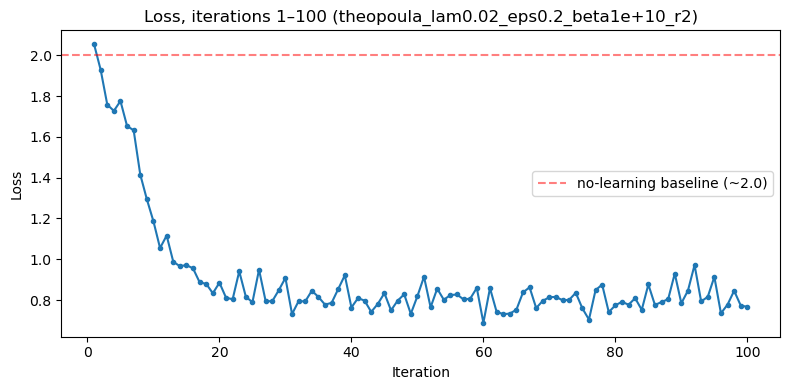

In [52]:
# checking the first 100 training losses for the best config
# 5 LAYER
best_tag = "theopoula_lam0.02_eps0.2_beta1e+10_r2"
loss_history = results[best_tag]["loss_history"]

for it, loss in enumerate(loss_history[:100], start=1):
    print(f"iter {it:3d}: loss = {loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 101), loss_history[:100], marker='o', markersize=3)
plt.axhline(2.0, color='red', linestyle='--', alpha=0.5, label='no-learning baseline (~2.0)')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"Loss, iterations 1–100 ({best_tag})")
plt.legend()
plt.tight_layout()
plt.show()

From the plot, we can see that the loss function in the objective is rapidly optimised, and then it levels out after 25 iterations. The injected noise is reason for the lack of convergence. (this was for a 5 layer network.)

### Comparing the fit from numerous different layers of network



In [53]:
import functions3 as fct
import numpy as np
import matplotlib.pyplot as plt

fct.set_seed(3)   # fresh seed for this large sampling pass
device = fct.get_device()

results = fct.load_results("outputs/depth_sweep_results.pt")

d = 2
T = 2
mu1 = np.array([1.3, 1.3])
mu2 = np.array([-1.3, -1.3])
sigma_mix = 1.0
weight = 0.5

X_data_bimodal = fct.sample_bimodal_data(
    N=1_000_000, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)

N_SAMPLES = 200_000

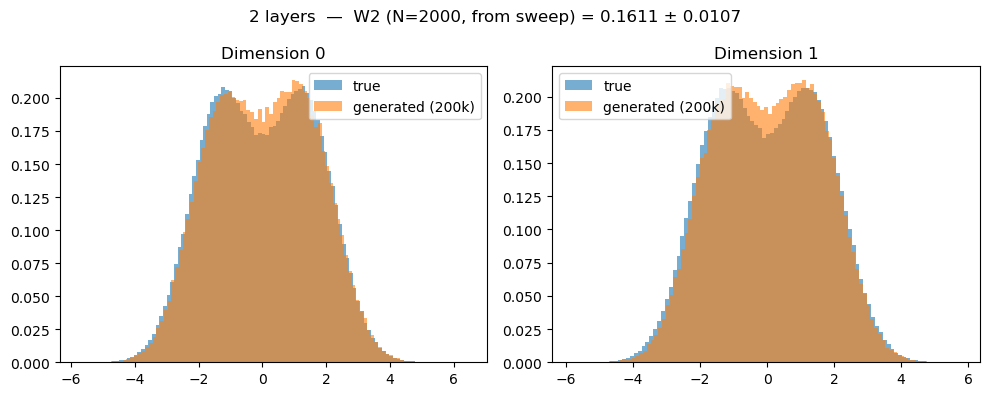

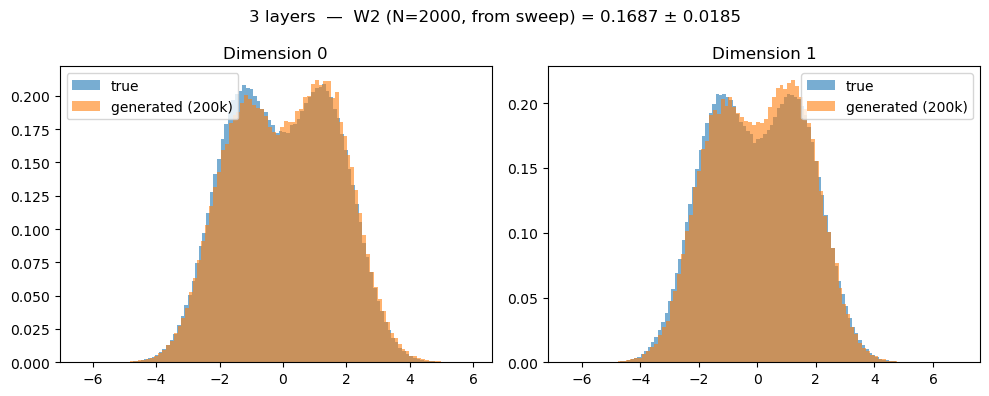

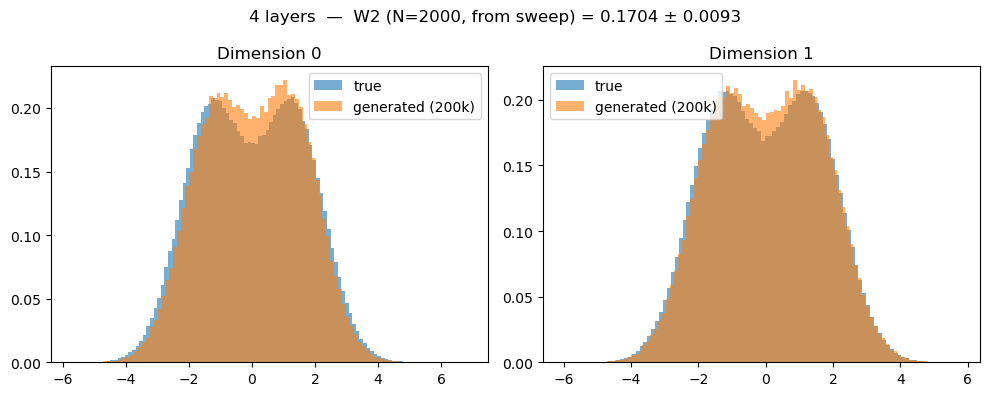

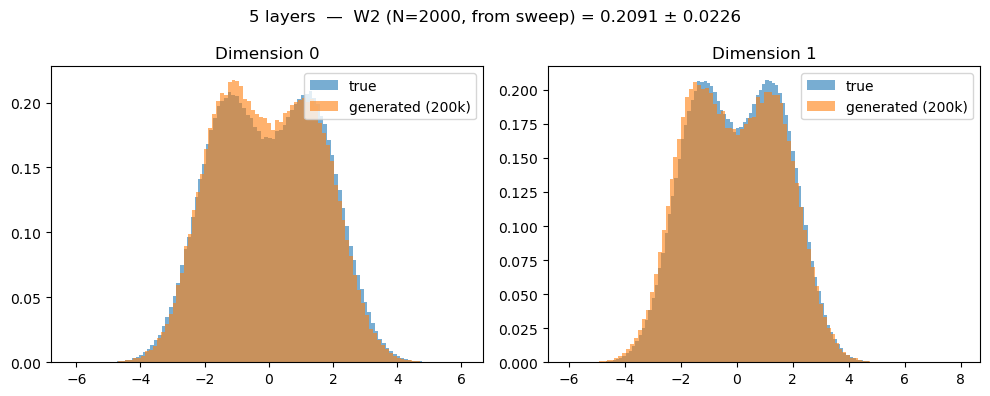

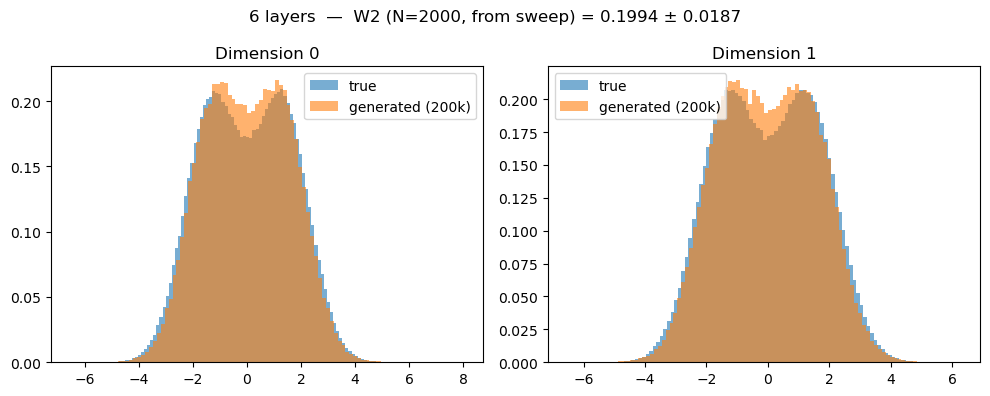

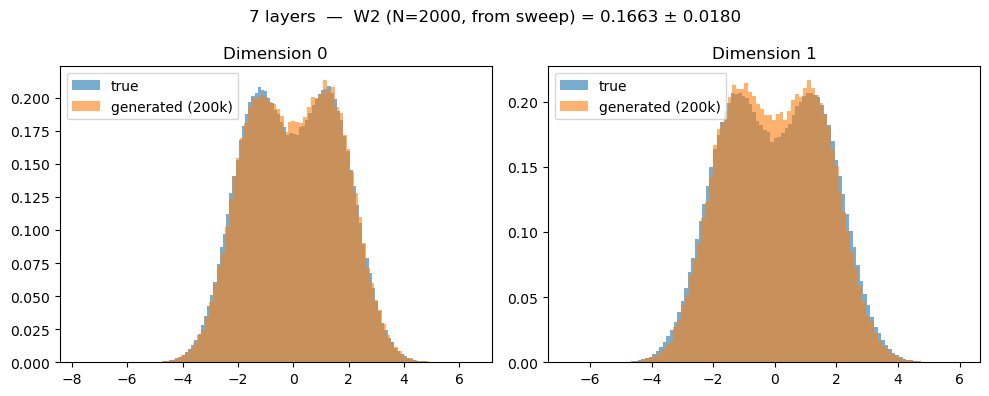

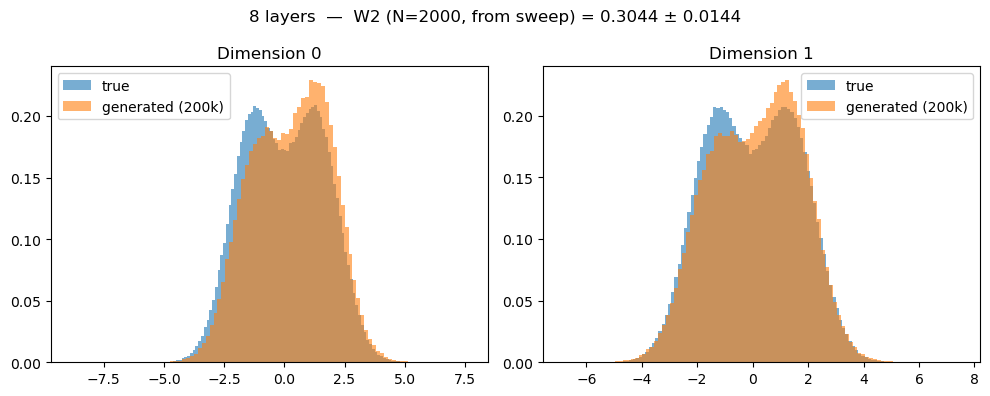

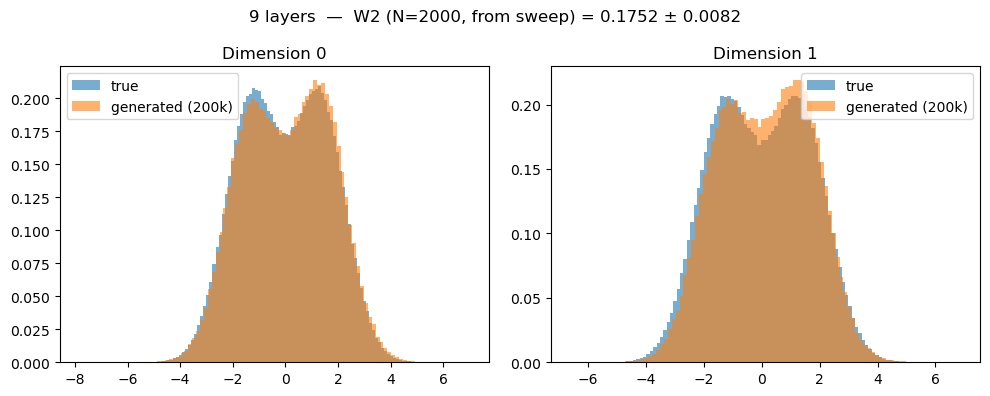

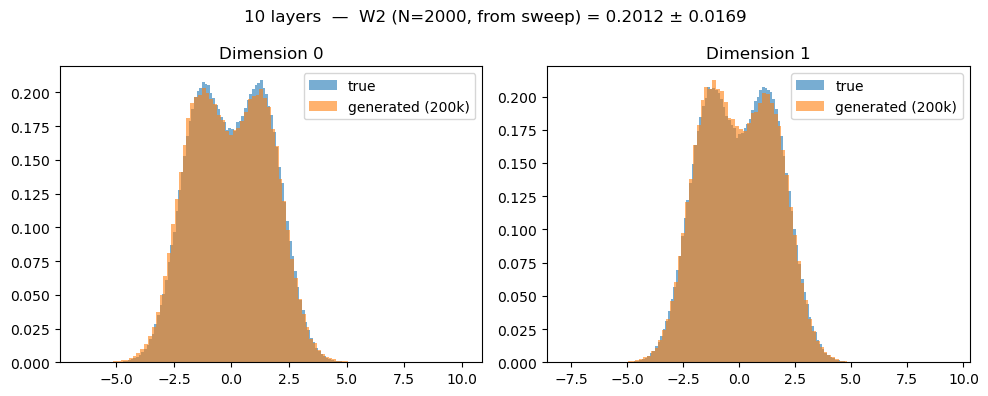

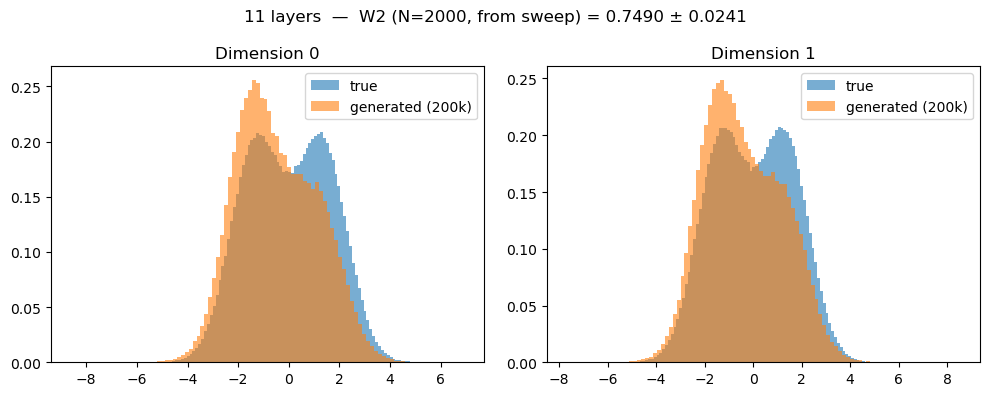

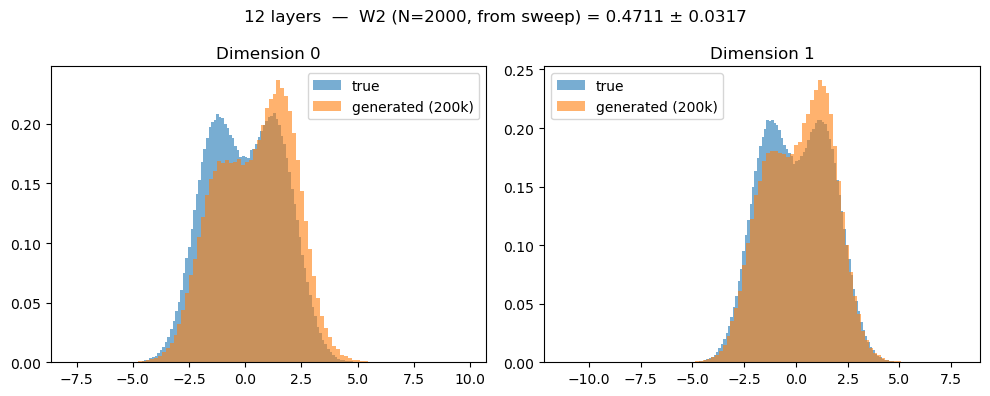

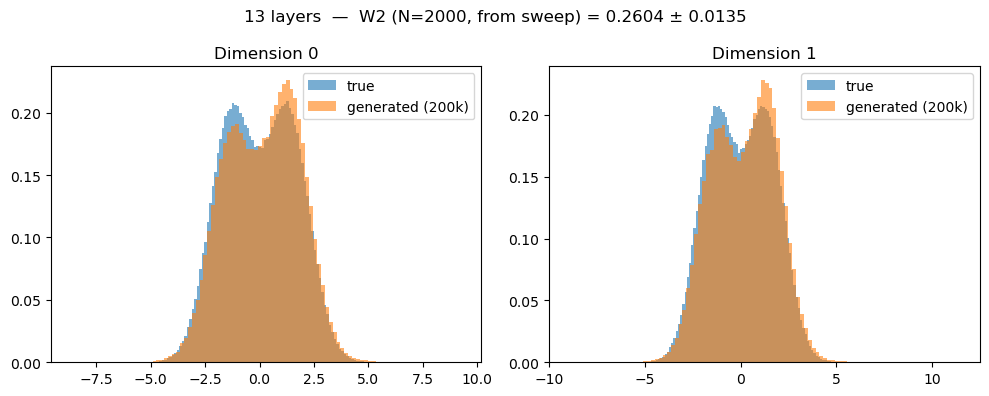

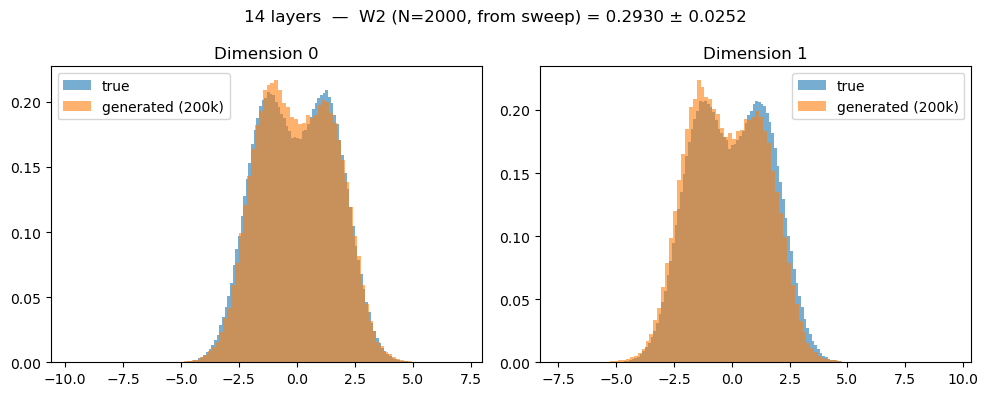

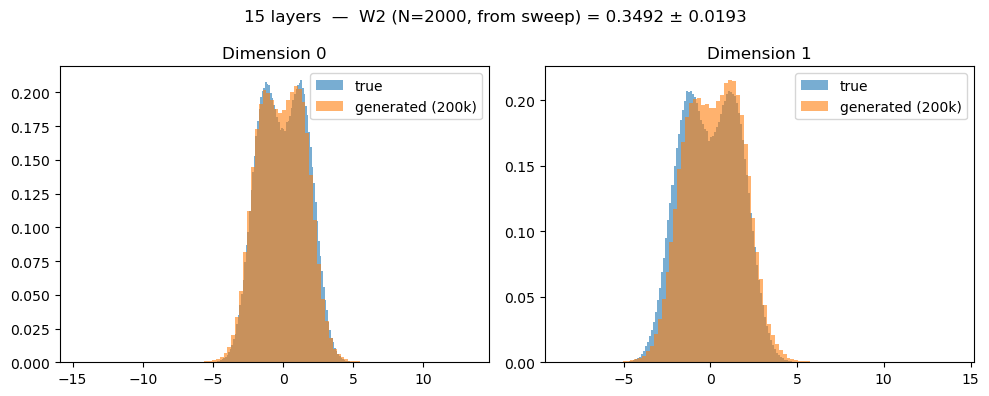

In [55]:
# ------------------------------------------------------------
# For each depth: rebuild the network from its saved state dict,
# draw 200,000 samples, and plot true vs generated per dimension.
# One figure per depth.
# ------------------------------------------------------------
for tag, res in sorted(results.items(), key=lambda kv: kv[1]["n_layers"]):
    n_layers = res["n_layers"]
    hidden_dims = res["hidden_dims"]

    net = fct.ScoreNetDeep(d=d, hidden_dims=hidden_dims).to(device)
    net.load_state_dict(res["net_state"])

    samples_200k = fct.euler_maruyama_sample_nn_batch(
        net, gamma=0.001, T=T, d=d, N_samples=N_SAMPLES, device=device
    )

    fig, axes = plt.subplots(1, d, figsize=(5 * d, 4))
    for i in range(d):
        axes[i].hist(X_data_bimodal[:, i], bins=100, alpha=0.6, label="true", density=True)
        axes[i].hist(samples_200k[:, i], bins=100, alpha=0.6, label=f"generated (200k)", density=True)
        axes[i].set_title(f"Dimension {i}")
        axes[i].legend()
    plt.suptitle(f"{n_layers} layers  —  W2 (N=2000, from sweep) = {res['w2_mean']:.4f} ± {res['w2_std']:.4f}")
    plt.tight_layout()
    plt.show()

# NEW EXPERIMENT
 - from run_experiment.py

In [6]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import functions4 as fct

OUT_DIR = "outputs"
SPECIAL = {"floors", "best_params", "gsweep"}

results, extra = {}, {}
for p in sorted(glob.glob(os.path.join(OUT_DIR, "*.pt"))):
    name = os.path.basename(p)[:-3]
    (extra if name in SPECIAL else results)[name] = fct.load_results(p)

floors = extra.get("floors", {})
print(f"{len(results)} runs loaded")
for k in sorted(results):
    print(" ", k)

20 runs loaded
  bimodal_adam_L2
  bimodal_adam_L20
  bimodal_sgld_L2
  bimodal_sgld_L20
  bimodal_theopoula_L2
  bimodal_theopoula_L20
  bimodal_tusla_L2
  bimodal_tusla_L20
  gaussian_adam_L2
  gaussian_adam_L20
  gaussian_adam_affine
  gaussian_sgld_L2
  gaussian_sgld_L20
  gaussian_sgld_affine
  gaussian_theopoula_L2
  gaussian_theopoula_L20
  gaussian_theopoula_affine
  gaussian_tusla_L2
  gaussian_tusla_L20
  gaussian_tusla_affine


In [7]:
print(f"{'tag':40s} {'W2':>9s} {'sd':>8s} {'floor':>8s} {'|theta|':>9s} "
      f"{'q':>5s} {'r_min':>6s} {'r':>5s} {'adm':>4s} {'div':>4s}")
for tag in sorted(results):
    r = results[tag]; c = r["config"]
    fl = floors.get(c["target"], {}).get("mean", float("nan"))
    tn = r["theta_norm_history"][-1] if r["theta_norm_history"] else float("nan")
    ru = r["r_used"]; ad = r["r_admissible"]
    print(f"{tag:40s} {r['w2_mean']:9.4f} {r['w2_std']:8.4f} {fl:8.4f} "
          f"{tn:9.2f} {r['q']:5.0f} {r['r_min_theopoula']:6.1f} "
          f"{('-' if ru is None else f'{ru:.1f}'):>5s} "
          f"{('-' if ad is None else ('y' if ad else 'N')):>4s} "
          f"{'yes' if r['diverged'] else 'no':>4s}")

print("\n" + fct.latex_table(
    results, floors,
    caption=(r"Empirical Wasserstein-2 distance between $N=10{,}000$ generated and "
             r"reference samples, reported against the finite-sample floor at the "
             r"same $N$. Both samples are redrawn on each of three repeats."),
    label="tab:w2_results"))

tag                                             W2       sd    floor   |theta|     q  r_min     r  adm  div
bimodal_adam_L2                             0.1227   0.0116   0.0938      8.67     3    1.5     -    -   no
bimodal_adam_L20                            0.2384   0.0071   0.0938     28.54    39   19.5     -    -   no
bimodal_sgld_L2                             0.2193   0.0185   0.0938      7.81     3    1.5     -    -   no
bimodal_sgld_L20                           12.6300   0.0295   0.0938     28.85    39   19.5     -    -   no
bimodal_theopoula_L2                        0.1519   0.0109   0.0938      7.64     3    1.5   2.0    y   no
bimodal_theopoula_L20                      12.5258   0.1239   0.0938     26.15    39   19.5   2.0    N   no
bimodal_tusla_L2                            0.7282   0.0159   0.0938      5.87     3    1.5   2.0    N   no
bimodal_tusla_L20                          12.5270   0.0396   0.0938     22.46    39   19.5   2.0    N   no
gaussian_adam_L2            

In [8]:
for tname, d_ in floors.items():
    print(f"{tname:10s} floor at N={d_['N']}: {d_['mean']:.4f} +/- {d_['std']:.4f}"
          f"   (repeats: {', '.join(f'{v:.4f}' for v in d_['all'])})")

gaussian   floor at N=10000: 0.0757 +/- 0.0029   (repeats: 0.0713, 0.0776, 0.0781, 0.0784, 0.0732)
bimodal    floor at N=10000: 0.0938 +/- 0.0061   (repeats: 0.0999, 0.1018, 0.0920, 0.0896, 0.0857)


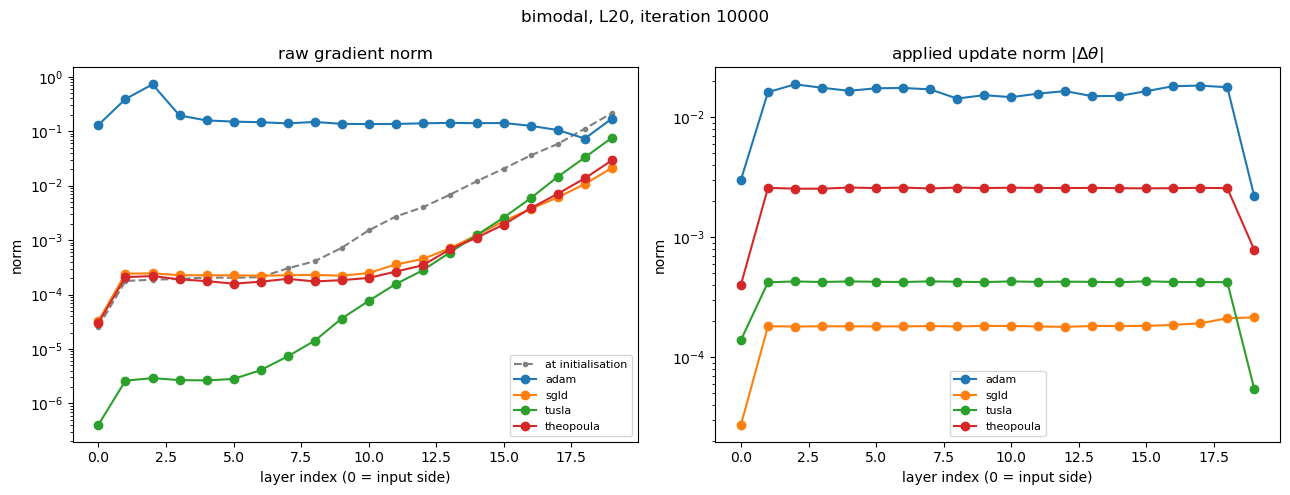

In [9]:
TARGET, ARCH, ITER = "bimodal", "L20", 10_000      # <-- change

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
first = True
for opt in ["adam", "sgld", "tusla", "theopoula"]:
    tag = f"{TARGET}_{opt}_{ARCH}"
    if tag not in results: continue
    r = results[tag]
    names = [n for n in r["grad_norms_init"] if n.endswith("weight")]
    if first:
        axes[0].plot([r["grad_norms_init"][n] for n in names], "--",
                     color="grey", marker="o", ms=3, label="at initialisation")
        first = False
    if ITER in r["grad_norms"]:
        axes[0].plot([r["grad_norms"][ITER][n] for n in names], marker="o", label=opt)
    if ITER in r["update_norms"]:
        axes[1].plot([r["update_norms"][ITER][n] for n in names], marker="o", label=opt)

axes[0].set_title("raw gradient norm")
axes[1].set_title(r"applied update norm $|\Delta\theta|$")
for ax in axes:
    ax.set_yscale("log"); ax.set_xlabel("layer index (0 = input side)")
    ax.set_ylabel("norm"); ax.legend(fontsize=8)
plt.suptitle(f"{TARGET}, {ARCH}, iteration {ITER}")
plt.tight_layout(); plt.show()

bimodal_adam_L2                  100.0% inside window, max |x| = 5.5
bimodal_theopoula_L2             100.0% inside window, max |x| = 5.9
bimodal_theopoula_L20             18.3% inside window, max |x| = 43.8


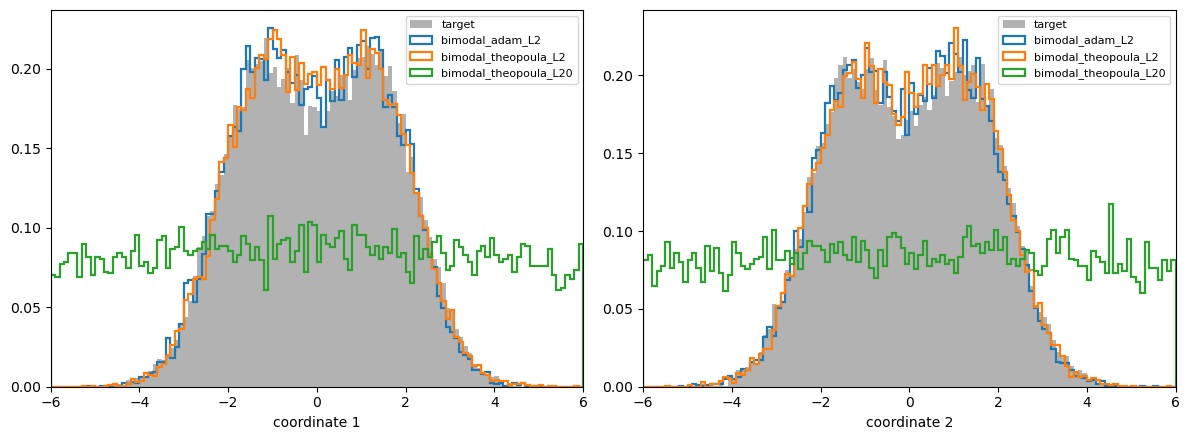

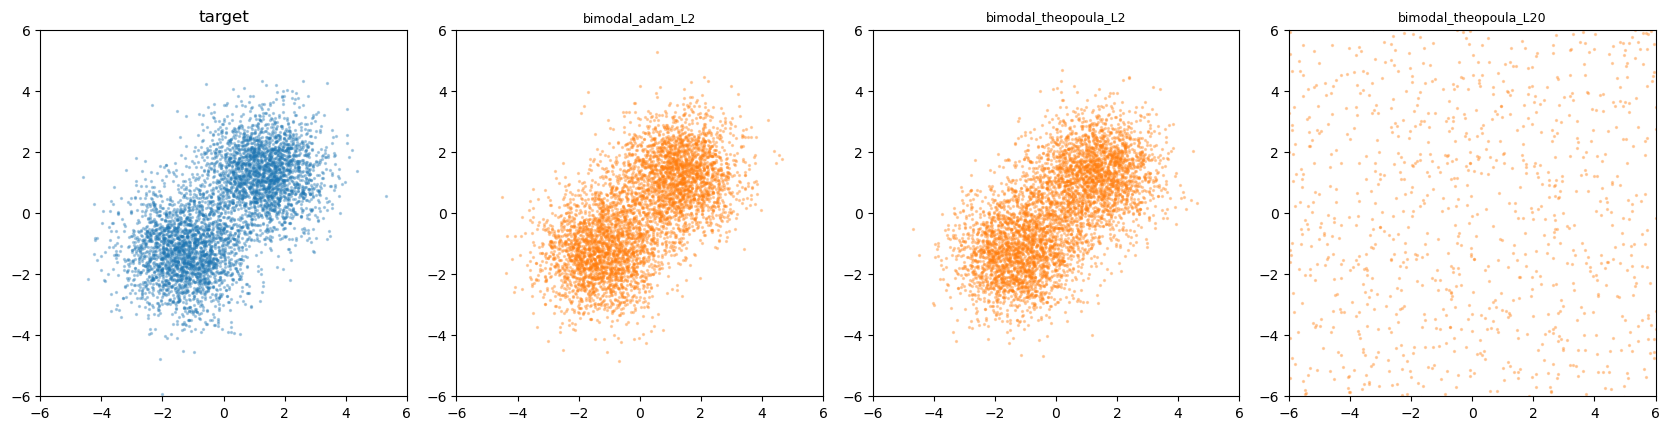

In [12]:
TAGS = ["bimodal_adam_L2", "bimodal_theopoula_L2", "bimodal_theopoula_L20"]  # <-- change
TARGET = "bimodal"
LIM = 6.0                                    # <-- axis limit, both plots
BINS = np.linspace(-LIM, LIM, 121)

target = fct.make_target(TARGET, 2, np.array([1.3, 1.3]), 1.0)
true = target["sample"](20_000)

# how much of each run actually lands in the window
for tag in TAGS:
    s = results.get(tag, {}).get("samples")
    if s is None:
        print(f"{tag:32s} no samples stored")
    else:
        frac = float(np.mean(np.all(np.abs(s) <= LIM, axis=1)))
        print(f"{tag:32s} {frac:6.1%} inside window, max |x| = {np.abs(s).max():.1f}")

# marginals
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for k in range(2):
    axes[k].hist(true[:, k], bins=BINS, density=True, alpha=0.3, color="k", label="target")
    for tag in TAGS:
        s = results.get(tag, {}).get("samples")
        if s is not None:
            axes[k].hist(s[:, k], bins=BINS, density=True, histtype="step",
                         lw=1.6, label=tag)
    axes[k].set_xlim(-LIM, LIM)
    axes[k].set_xlabel(f"coordinate {k+1}")
    axes[k].legend(fontsize=8)
plt.tight_layout(); plt.show()

# scatter
fig, axes = plt.subplots(1, len(TAGS) + 1, figsize=(4.2 * (len(TAGS) + 1), 4.2))
axes[0].scatter(true[:5000, 0], true[:5000, 1], s=2, alpha=0.3)
axes[0].set_title("target")
for ax, tag in zip(axes[1:], TAGS):
    s = results.get(tag, {}).get("samples")
    if s is not None:
        ax.scatter(s[:5000, 0], s[:5000, 1], s=2, alpha=0.3, color="C1")
    ax.set_title(tag, fontsize=9)
for ax in axes:
    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [ ]:
TAG = "bimodal_theopoula_L2"   # <-- change

grid = results[TAG]["score_grid"]
ts = sorted(grid)
fig, axes = plt.subplots(1, len(ts), figsize=(5 * len(ts), 5))
for ax, t in zip(np.atleast_1d(axes), ts):
    g = grid[t]; X, Sp, St = g["X"], g["S_pred"], g["S_true"]
    ax.quiver(X[:, 0], X[:, 1], St[:, 0], St[:, 1], color="k", alpha=0.4)
    ax.quiver(X[:, 0], X[:, 1], Sp[:, 0], Sp[:, 1], color="C3", alpha=0.75)
    ax.set_title(f"t = {t:g}   (black: true, red: learned)", fontsize=9)
    ax.set_aspect("equal")
plt.suptitle(TAG); plt.tight_layout(); plt.show()

In [ ]:
TARGET, ARCH = "bimodal", "L2"   # <-- change

plt.figure(figsize=(6.5, 4.5))
for opt in ["adam", "sgld", "tusla", "theopoula"]:
    tag = f"{TARGET}_{opt}_{ARCH}"
    se = results.get(tag, {}).get("score_error")
    if se:
        ts = sorted(se)
        plt.plot(ts, [se[t] for t in ts], marker="o", label=opt)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("t"); plt.ylabel(r"$\mathcal{E}(t)$")
plt.title(f"score error against noise level: {TARGET}, {ARCH}")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
TARGET, ARCH = "bimodal", "L20"   # <-- change

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for opt in ["adam", "sgld", "tusla", "theopoula"]:
    tag = f"{TARGET}_{opt}_{ARCH}"
    if tag not in results: continue
    r = results[tag]
    axes[0].plot(r["loss_history"], lw=1, alpha=0.85, label=opt)
    axes[1].plot(r["theta_norm_history"], lw=1, alpha=0.85, label=opt)
axes[0].set_yscale("log"); axes[0].set_ylabel("loss")
axes[1].set_ylabel(r"$|\theta|$")
for ax in axes: ax.set_xlabel("iteration"); ax.legend()
plt.suptitle(f"{TARGET}, {ARCH}"); plt.tight_layout(); plt.show()